# Distribution functions

`phasegen` exposes the full distribution of any accumulated coalescent reward (tree height, total branch length, an individual SFS bin's branch length, or any {doc}`custom reward <rewards>`) as callable, plottable distribution-function objects (`pdf`, `cdf`, `quantile`). They are analytically exact, obtained by numerically inverting the reward's Laplace transform rather than by sampling, though the inversion can lose precision for extreme demographies.

```{versionadded} 2.0
```

Any two rewards additionally have a joint distribution, from which the {meth}`JointRewardDistribution.marginal <phasegen.distributions.JointRewardDistribution.marginal>` and {meth}`JointRewardDistribution.conditional <phasegen.distributions.JointRewardDistribution.conditional>` distributions of one given the other follow.

In [1]:
import matplotlib.pyplot as plt

plt.rcParams['figure.figsize'] = (5, 4)

In [2]:
import phasegen as pg

In [3]:
# keep the rendered docs clean: silence informational logging and warnings
import logging
import warnings

logging.getLogger('phasegen').setLevel(logging.ERROR)
warnings.filterwarnings('ignore')

## One-dimensional reward distributions

Take a single population through a sharp bottleneck. Its {meth}`Coalescent.total_branch_length <phasegen.distributions.Coalescent.total_branch_length>`, the summed length of every branch in the tree, is a distribution whose `pdf`, `cdf` and `quantile` are callable at points and plottable.

In [4]:
coal = pg.Coalescent(
    n=8,
    demography=pg.Demography(pop_sizes={'pop_0': {0: 1.0, 0.25: 0.08, 0.7: 1.0}}),
)

tbl = coal.total_branch_length

print(f"f(1.5)     = {tbl.pdf(1.5):.3f}")
print(f"P(L <= 2)  = {tbl.cdf(2.0):.3f}")
print(f"median     = {tbl.quantile(0.5):.3f}")

f(1.5)     = 1.022
P(L <= 2)  = 0.814


median     = 1.730


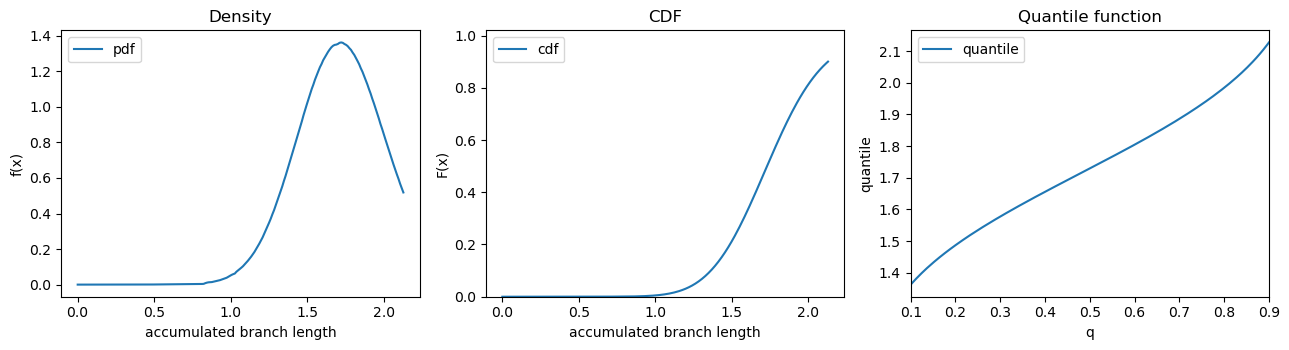

In [5]:
_, axs = plt.subplots(ncols=3, figsize=(13, 3.6))
tbl.pdf.plot(ax=axs[0], show=False, title='Density')
tbl.cdf.plot(ax=axs[1], show=False, title='CDF')
tbl.quantile.plot(ax=axs[2], title='Quantile function');

The `quantile` is the inverse of the `cdf`: `quantile(0.5)` is the median, `quantile(0.9)` the branch length exceeded only one time in ten.

## Joint distributions

Any two accumulated rewards have a joint distribution. {meth}`UnfoldedSFSDistribution.joint_distribution <phasegen.distributions.UnfoldedSFSDistribution.joint_distribution>` returns it as a {class}`~phasegen.distributions.JointRewardDistribution` with a 2D `pdf` and `cdf` (a joint quantile is not well-defined). As an example, take two rewards from the bottleneck above, the singleton and doubleton branch lengths (SFS bins 1 and 2). They are not independent: within a tree, branch length subtending one frequency class reduces that available to the other, so their joint distribution is bimodal and negatively correlated.

In [6]:
joint = coal.sfs.joint_distribution(1, 2)  # singleton and doubleton branch lengths

print(f"P(R_a <= 1.5, R_b <= 0.5) = {joint.cdf(1.5, 0.5):.3f}")
print(f"means (E[R_a], E[R_b])    = {joint.mean.round(3)}")
print(f"correlation               = {joint.corr():.3f}")

P(R_a <= 1.5, R_b <= 0.5) = 0.694
means (E[R_a], E[R_b])    = [1.132 0.325]
correlation               = -0.307


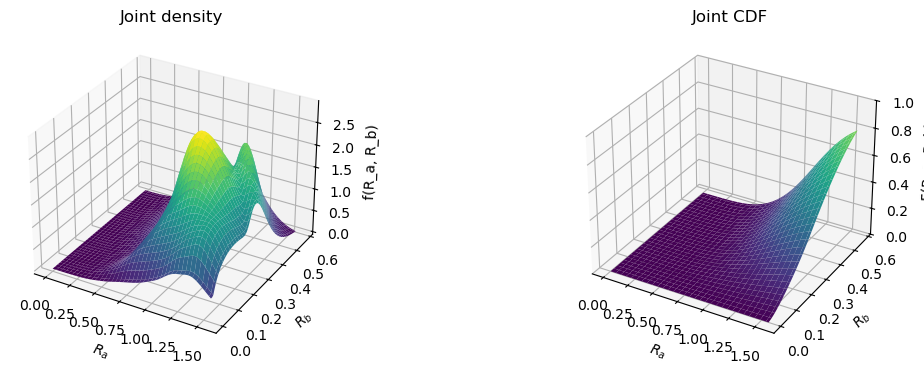

In [7]:
fig, axs = plt.subplots(ncols=2, figsize=(11, 4.2), subplot_kw={'projection': '3d'})
joint.pdf.plot_surface(ax=axs[0], show=False, title='Joint density')
joint.cdf.plot_surface(ax=axs[1], title='Joint CDF')
fig.subplots_adjust(left=0.02, right=0.98, wspace=0.12);

## Marginal distributions

{meth}`JointRewardDistribution.marginal <phasegen.distributions.JointRewardDistribution.marginal>` collapses the joint distribution onto one axis, recovering the ordinary 1D distribution of that reward, here identical to accessing the SFS bin directly via {meth}`UnfoldedSFSDistribution.bin <phasegen.distributions.UnfoldedSFSDistribution.bin>`.

marginal mean = 1.1324   (bin 1 mean = 1.1324)


<Axes: title={'center': 'Marginal vs. direct bin density'}, xlabel='x', ylabel='f(x)'>

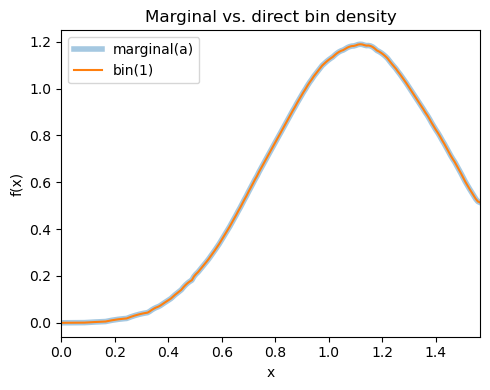

In [8]:
marg = joint.marginal('a')  # branch length of bin 1 (singletons)
print(f"marginal mean = {marg.mean:.4f}   (bin 1 mean = {coal.sfs.bin(1).mean:.4f})")

_, ax = plt.subplots()
marg.pdf.plot(ax=ax, show=False, label='marginal(a)', lw=4, alpha=0.4)
coal.sfs.bin(1).pdf.plot(ax=ax, label='bin(1)', title='Marginal vs. direct bin density', lw=1.5)

## Conditional distributions

{meth}`JointRewardDistribution.conditional <phasegen.distributions.JointRewardDistribution.conditional>` gives the 1D distribution of one reward given the other equals a fixed value. Because the two rewards are negatively correlated, the doubleton length shifts left as the conditioning singleton length grows. Conditioning on a *short* singleton branch leaves the doubleton length bimodal, reflecting whether lineages coalesced during or after the bottleneck; conditioning on a *long* one collapses it to a single mode.

In [9]:
print("E[R_b | R_a = v]:")
for v in [0.4, 0.9, 1.4]:
    print(f"  v = {v}:  {joint.conditional('a', v).mean:.3f}")

E[R_b | R_a = v]:
  v = 0.4:  0.452
  v = 0.9:  0.363
  v = 1.4:  0.283


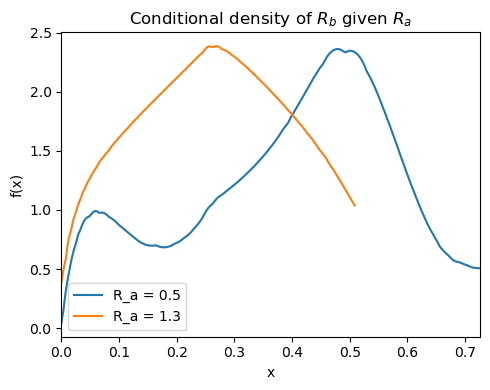

In [10]:
_, ax = plt.subplots()
for v in [0.5, 1.3]:
    joint.conditional('a', v).pdf.plot(ax=ax, show=False, label=f'R_a = {v}',
                                       title='Conditional density of $R_b$ given $R_a$');

## Checking against the sampler

Every one of these objects has an empirical counterpart from {meth}`PhaseTypeDistribution.to_empirical <phasegen.distributions.PhaseTypeDistribution.to_empirical>` (see {doc}`Empirical distributions <empirical_distributions>`), drawn from the same model by Monte Carlo, with the empirical {meth}`EmpiricalPhaseTypeSFSDistribution.joint_distribution <phasegen.distributions.EmpiricalPhaseTypeSFSDistribution.joint_distribution>` exposing the matching {meth}`EmpiricalJointRewardDistribution.marginal <phasegen.distributions.EmpiricalJointRewardDistribution.marginal>` and {meth}`EmpiricalJointRewardDistribution.conditional <phasegen.distributions.EmpiricalJointRewardDistribution.conditional>`. This independently validates the exact results, which is valuable because the Laplace-transform inversion can lose precision for extreme demographies. The sampled conditional is only approximate, since it is estimated by restricting the unconditioned sample to a narrow window around the conditioning value rather than drawn from the conditional law directly, but it is close enough to confirm the exact densities that coincide with it below.

correlation:  exact -0.307   sampled -0.308


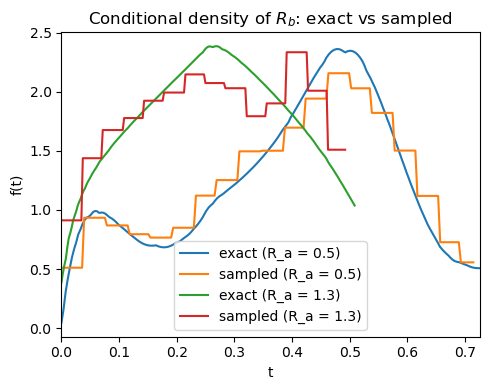

In [11]:
emp = coal.sfs.to_empirical(1_000_000).joint_distribution(1, 2)
print(f"correlation:  exact {joint.corr():+.3f}   sampled {emp.corr():+.3f}")

_, ax = plt.subplots()
for v in [0.5, 1.3]:
    joint.conditional('a', v).pdf.plot(ax=ax, show=False, label=f'exact (R_a = {v})')
    emp.conditional('a', v).pdf.plot(ax=ax, show=(v == 1.3), label=f'sampled (R_a = {v})',
                                     title='Conditional density of $R_b$: exact vs sampled')